In [83]:
from openai import OpenAI
import os
import pandas as pd
import time
import json
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [84]:
# Initialize the OpenAI client with API key.
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY")) # specified value was saved

if client.api_key is None:
    raise ValueError("OPENAI_API_KEY environment variable not set")

In [85]:
# Read the few-shot prompt from the external file
prompt_path = 'C:/Users/ntanavarass/Desktop/Conversational-Triple-Extraction/data annotation/annotation_prompt.txt'

with open(prompt_path, 'r') as file:
    PROMPT = file.read()

In [86]:
# Read the test data
test_data = pd.read_csv('C:/Users/ntanavarass/Desktop/Conversational-Triple-Extraction/final data/expanded_test_data.csv')
test_data

,sentence_id,token_id,sentence,token,spo_label
0,1,1,P : I have been facing some discomfort in my f...,P,other
1,1,2,P : I have been facing some discomfort in my f...,:,other
2,1,3,P : I have been facing some discomfort in my f...,I,Subject
3,1,4,P : I have been facing some discomfort in my f...,have,Predicate
4,1,5,P : I have been facing some discomfort in my f...,been,Predicate
...,...,...,...,...,...
13905,996,8,It is all about achieving a balance that suits...,that,other
13906,996,9,It is all about achieving a balance that suits...,suits,other
13907,996,10,It is all about achieving a balance that suits...,your,other
13908,996,11,It is all about achieving a balance that suits...,lifestyle,other


In [72]:
def dynamic_chunking(data, max_chunk_size):
    chunks = []  # A list to store all chunks of sentences.
    current_chunk = []  # A list to accumulate sentences into the current chunk.

    # Group by 'sentence_id' and take the first sentence from each group.
    unique_data = data.groupby('sentence_id').first().reset_index()
    sentences = unique_data['sentence'].tolist()
    sentence_ids = unique_data['sentence_id'].tolist()

    i = 0  
    while i < len(sentences):
        sentence = sentences[i]
        sentence_id = sentence_ids[i]
        current_chunk.append((sentence_id, sentence))  # Append tuple of sentence ID and sentence.
        
        # Check if the sentence ends with a question mark and ensure there are at least two more sentences.
        if sentence.strip().endswith('?') and (i + 2 < len(sentences)):
            # Add the next two sentences to the same chunk.
            current_chunk.extend([(sentence_ids[i + 1], sentences[i + 1]), (sentence_ids[i + 2], sentences[i + 2])])
            i += 2
        
        # Check if the current chunk should be closed.
        if len(current_chunk) >= max_chunk_size or (i + 1 < len(sentences) and sentences[i + 1].startswith("New topic:")):
            chunks.append(current_chunk)
            current_chunk = []

        i += 1

    if current_chunk:
        chunks.append(current_chunk)

    return chunks


def extract_spo_labels(PROMPT, text_tuples):
    formatted_text = "\n".join(f"Sentence ID: {tid}\n{txt}" for tid, txt in text_tuples)
    response = client.chat.completions.create(
        model = "gpt-4o",
        messages = [
            {"role": "system", "content": PROMPT},
            {"role": "user", "content": formatted_text}
        ],
        max_tokens = 4096,
        temperature = 0.2  # affects the randomness or creativity of the responses produced by the model
    )

    if response.choices:
        api_output = response.choices[0].message.content

        unwanted_prefix = "```json\n["
        unwanted_suffix = "```"
        if api_output.startswith(unwanted_prefix):
            api_output = api_output[len(unwanted_prefix):]  # Remove the specific prefix
        if api_output.endswith(unwanted_suffix):
            api_output = api_output[:-len(unwanted_suffix)]  # Remove the specific suffix
        return api_output.strip()  # Remove any extra whitespace
    else:
        raise ValueError("No valid response received from the API")
    

def save_extracted_labels(annotations, output_file):
    try:
        with open(output_file, 'w', encoding='utf-8') as file:
            # Start the JSON array
            file.write("[\n")
            
            # Write annotations as continuous entries in the JSON array
            for i, annotation in enumerate(annotations):
                # Remove the surrounding square brackets from each annotation chunk if present
                if annotation.startswith('[') and annotation.endswith(']'):
                    annotation = annotation[1:-1]  # Remove the first '[' and last ']'
                
                # Add a comma between entries, but not before the first entry
                if i > 0:
                    file.write(",\n")
                
                file.write(annotation)
            
            # Close the JSON array
            file.write("\n]")
            
        print("Annotations saved successfully.")
    except Exception as e:
        print(f"Failed to save annotations: {e}")


def main(prompt, output_file):
    try:
        chunks = dynamic_chunking(test_data, 1)

        annotations = []
        for chunk in chunks:
            response = extract_spo_labels(prompt, chunk)  
            annotations.append(response)
            save_extracted_labels(annotations, output_file)
            
    except Exception as e:
        print(f"An error occurred: {str(e)}")


In [73]:
main(PROMPT, 'C:/Users/ntanavarass/Desktop/Conversational-Triple-Extraction/cte/gpt4o/results/gpt4o_results.json')

Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotations saved successfully.
Annotati

In [78]:
# Transform the JSON file into a CSV
few_shot_results = 'C:/Users/ntanavarass/Desktop/Conversational-Triple-Extraction-1/models/GPT4o_results.json'

with open(few_shot_results, 'r') as file:
    results = file.read()

predictions = json.loads(results)
df = pd.json_normalize(predictions)

# Since 'sentence' repeats, keep only the first occurrence with each 'sentence_id'
df['sentence'] = df.groupby('sentence_id')['sentence'].transform('first')
df.drop_duplicates(subset=['sentence_id', 'token_id'], inplace=True)

# Select and rename columns as necessary
df_final = df[['sentence_id', 'token_id', 'sentence', 'token', 'spo_label']]

# Export to CSV
df_final.to_csv('gpt4o_results.csv', index=False)

In [87]:
gpt4o_predictions = pd.read_csv('C:/Users/ntanavarass/Desktop/Conversational-Triple-Extraction-1/models/gpt4o_results.csv')
gpt4o_predictions

,sentence_id,token_id,sentence,token,spo_label
0,1,1,P : I have been facing some discomfort in my f...,P,other
1,1,2,P : I have been facing some discomfort in my f...,:,other
2,1,3,P : I have been facing some discomfort in my f...,I,Subject
3,1,4,P : I have been facing some discomfort in my f...,have,Predicate
4,1,5,P : I have been facing some discomfort in my f...,been,Predicate
...,...,...,...,...,...
13905,996,8,It is all about achieving a balance that suits...,that,Object
13906,996,9,It is all about achieving a balance that suits...,suits,Object
13907,996,10,It is all about achieving a balance that suits...,your,Object
13908,996,11,It is all about achieving a balance that suits...,lifestyle,Object


Precision: 0.6833
Recall: 0.7265
F1 Score: 0.6801


<Figure size 1000x1000 with 0 Axes>

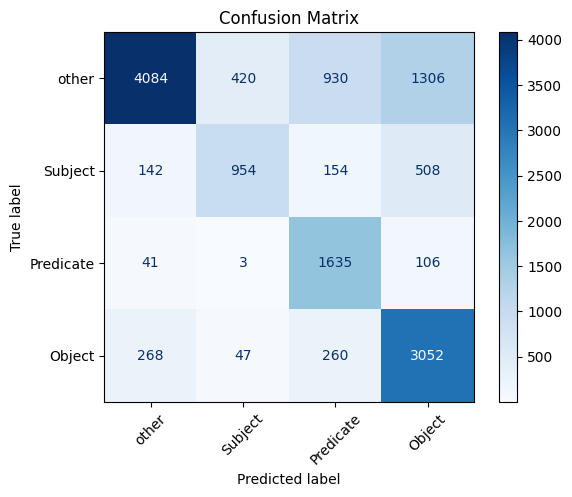

In [88]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# Make sure both dataframes are sorted by sentence_id and token_id to align them correctly
test_data.sort_values(by=['sentence_id', 'token_id'], inplace=True)
gpt4o_predictions.sort_values(by=['sentence_id', 'token_id'], inplace=True)

# Check if both DataFrames have the same order
if not test_data[['sentence_id', 'token_id']].equals(gpt4o_predictions[['sentence_id', 'token_id']]):
    raise ValueError("The order of rows in the test data and predictions does not match.")

# Calculate Precision, Recall, and F1-Score
metrics = precision_recall_fscore_support(test_data['spo_label'], gpt4o_predictions['spo_label'], average='macro')
precision, recall, f1_score, _ = metrics

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")

# Generate Confusion Matrix
cm = confusion_matrix(test_data['spo_label'], gpt4o_predictions['spo_label'], labels=pd.unique(test_data['spo_label']))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pd.unique(test_data['spo_label']))

# Plot Confusion Matrix
plt.figure(figsize=(10,10))
disp.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=45)
plt.title('Confusion Matrix')
plt.show()


In [76]:
# def combine_labels(df):
#     """
#     Combines labels from multiple columns into a set for each row.
    
#     """
#     df['combined_labels'] = df.apply(lambda row: set(filter(lambda x: x != '_', [row['spo_label_1'], row['spo_label_2'], row['spo_label_3']])), axis=1)
#     return df


# def calculate_partial_metrics(aligned_df):
#     """
#     Calculates precision, recall, and F1-score considering partial matches.
    
#     """
#     def matching_labels_count(row):
#         """
#         Takes a single row of the Df as input and calculates the count of matches and the total counts of predicted and gold labels for that row.
        
#         """
#         pred_labels = set(row['label_str_pred'].split(';')) # Converts the predicted labels into a set of strings
#         gold_labels = set(row['label_str_gold'].split(';')) # Converts the gold labels into a set of strings

#         return len(pred_labels.intersection(gold_labels)), len(pred_labels), len(gold_labels)  
    

    
#     counts = aligned_df.apply(matching_labels_count, axis=1, result_type='expand') # Each of the output values is expanded into separate columns in the Df
#     aligned_df['matches'], aligned_df['pred_count'], aligned_df['gold_count'] = counts[0], counts[1], counts[2]
    
#     precision_partial = aligned_df['matches'].sum() / aligned_df['pred_count'].sum() if aligned_df['pred_count'].sum() > 0 else 0
#     recall_partial = aligned_df['matches'].sum() / aligned_df['gold_count'].sum() if aligned_df['gold_count'].sum() > 0 else 0
#     f1_partial = 2 * (precision_partial * recall_partial) / (precision_partial + recall_partial) if (precision_partial + recall_partial) > 0 else 0
    
#     return precision_partial, recall_partial, f1_partial


# def generate_confusion_matrix(aligned_df):
#     """
#     Generates and plots the confusion matrix for multilabel data.
    
#     """
#     # Identify all unique label combinations
#     unique_labels = sorted(set(aligned_df['label_str_pred'].unique()).union(set(aligned_df['label_str_gold'].unique())))
    
#     # Create a mapping of label combinations to indices
#     label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
    
#     # Map the labels in the DataFrame to indices
#     y_pred_indices = aligned_df['label_str_pred'].map(label_to_index)
#     y_true_indices = aligned_df['label_str_gold'].map(label_to_index)
    
#     # Generate the confusion matrix
#     cm = confusion_matrix(y_true_indices, y_pred_indices, labels=range(len(unique_labels)))
    
#     # Plot the confusion matrix
#     plt.figure(figsize=(12, 12))
#     disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_labels)
#     disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
#     plt.title('Confusion Matrix for SPO Label Combinations')
#     plt.show()

#     return cm



# predictions_df = combine_labels(fsl_predictions)
# gold_labels_df = combine_labels(test_data)

# # Merge datasets on sentence_id and token_id to ensure alignment
# aligned_df = pd.merge(predictions_df, gold_labels_df, on=['sentence_id', 'token_id'], suffixes=('_pred', '_gold'))

# # Convert sets to sorted strings for evaluation
# aligned_df['label_str_pred'] = aligned_df['combined_labels_pred'].apply(lambda x: ';'.join(sorted(x)))
# aligned_df['label_str_gold'] = aligned_df['combined_labels_gold'].apply(lambda x: ';'.join(sorted(x)))

# # Calculate standard metrics
# precision = precision_score(aligned_df['label_str_gold'], aligned_df['label_str_pred'], average='weighted')
# recall = recall_score(aligned_df['label_str_gold'], aligned_df['label_str_pred'], average='weighted')
# f1 = f1_score(aligned_df['label_str_gold'], aligned_df['label_str_pred'], average='weighted')

# # Calculate modified metrics for partial matches
# precision_partial, recall_partial, f1_partial = calculate_partial_metrics(aligned_df)

# print("Standard Metrics:")
# print(f"Precision: {precision}, Recall: {recall}, F1-score: {f1}")
# print("Modified Metrics for Partial Matches:")
# print(f"Precision: {precision_partial}, Recall: {recall_partial}, F1-score: {f1_partial}")

# confusion_matrix_result = generate_confusion_matrix(aligned_df)

- In the confusion matrix each column and each row represents all the possible unique combinations of SPO labels that were identified within both the prediction and gold label files. 
- The order of labels within a set does not matter, "Object;Predicate" would be considered the same as "Predicate;Object".
- If the model predicts one correct label out of two total predictions (assuming the second prediction is incorrect or missing), the precision contribution for that token would be 0.5 (one correct out of two predicted). Similarly, if the gold standard expects two labels and the model correctly predicts one of them, the recall contribution for that token would be 0.5 (one correct out of two actual). This metric would balance the precision and recall, and for a token with these characteristics (precision = 0.5, recall = 0.5), the F1 would also be 0.5 for that token. 
- In the confusion matrix: The correct prediction contributes to a non-diagonal element (indicating a partial match but not a full match), which shows that while the model captured some aspect of the token's role, it didn't fully capture the complete labeling as expected in the gold standard.

This partial matching approach provides a more nuanced view of the model's performance, highlighting areas where it might be partially understanding the context but not fully grasping all the nuances. 

